<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8012/blob/main/laboratorioCalificado4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAESTRIA DE CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL
## VISION COMPUTACIONAL
### LABORATORIO CALIFICADO 4
### INTEGRANTES:
####   * David Jimenez
####   * José Carlos Nomberto

## 1. Interpretación de Métricas

### P (Precisión) y R (Recall) en la Tabla I:

* P (Precisión): Representa la proporción de detecciones de cuadros delimitadores positivas que fueron correctas (TP - True Positives). En la Tabla I, la precisión global (all) es de 0.782, lo que significa que el 78.2% de los cuadros delimitadores predichos corresponden realmente a la célula indicada. La clase con mayor precisión es WBC con 0.908.  
* R (Recall / Sensibilidad): Indica la proporción de objetos reales que el modelo logró detectar. El recall global es de 0.823, lo que significa que el modelo es capaz de identificar el 82.3% de todas las células presentes en las imágenes médicas.

### Diferencia entre mAP50 y mAP50-95:

* mAP50: Es la precisión media promedio calculada con un umbral de Intersección sobre Unión (IoU) fijo de 0.50. Mide qué tan buena es la capacidad del modelo para localizar y clasificar de forma general el objeto.  
* mAP50-95: Es una métrica mucho más estricta que calcula el promedio del mAP variando el umbral de IoU desde 0.50 hasta 0.95 con pasos de 0.05. Evaluamos ambos porque mAP50 nos da una noción de la capacidad de detección general, mientras que mAP50-95 evalúa la precisión y calidad milimétrica de la regresión de las cajas delimitadoras.

### Comparación Global (Tabla I vs. Tabla II)

* El experimento de la Tabla II obtuvo el mejor desempeño global. Al evaluar la fila all, se observa que todas sus métricas superan consistentemente a las de la Tabla I: la Precisión subió de 0.782 a 0.839, el Recall se incrementó de 0.823 a 0.909, el mAP50 se elevó de 0.866 a 0.933 y el mAP50-95 pasó de 0.547 a 0.631

### Análisis de la clase Platelets (Plaquetas)

* El experimento de la Tabla II es superior para las plaquetas. Aunque en la Tabla I se obtuvo una precisión ligeramente mayor (0.759 frente a 0.741), el Recall en la Tabla II aumentó drásticamente de 0.817 a 0.929. En el contexto clínico de conteo sanguíneo, un Recall significativamente más alto implica que se están dejando de detectar muy pocas plaquetas (menos falsos negativos), lo cual es crucial para la confiabilidad del conteo y compensa la mínima variación en precisión.

## 2. Fine Tuning

* Mantén las siguientes restricciones: modelo YOLOv8n, ≤ 50 épocas, imgsz ≤ 640.
* Haz Fine-Tuning para lograr que mAP50-95 supere cada clase de la Tabla I y II.

### 1. Instalar ultralytics

In [ ]:
!pip -q install ultralytics # Instalamos Ultralytics (nos permitirá usar YOLO)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.6 MB/s eta 0:00:00


### 2. Descomprimir dataset

In [ ]:
!unzip datasets.zip

Archive:  datasets.zip
   creating: datasets/
   creating: datasets/BCCD/
   creating: datasets/BCCD/labels/
   creating: datasets/BCCD/labels/train/
  inflating: datasets/BCCD/labels/train/BloodImage_00339.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00287.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00107.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00305.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00089.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00311.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00199.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00193.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00204.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00077.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00083.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00247.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00212.txt  
  inflating: datasets/BCCD/labe

### 3. Importar librerias

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### 4. Cargar el modelo YOLOv8 preentrenado

In [ ]:
MODEL_BASE = "yolov8n.pt"

print(f"--- Iniciando Fine-Tuning de {MODEL_BASE} ---")

# Cargar el modelo YOLOv8n preentrenado en COCO
model_ft = YOLO(MODEL_BASE)

--- Iniciando Fine-Tuning de yolov8n.pt ---


### 5. Definir constantes e hiperparámetros

In [ ]:
#DATA_YAML = "bccd.yaml"            # Archivo de configuración del dataset BCCD
#MAX_EPOCHS = 50                    # Restricción: Máximo de 50 épocas
#IMAGE_SIZE = 640                   # Restricción: Tamaño de imagen <= 640
#BATCH_SIZE = 16                    # Tamaño de lote balanceado para estabilidad y VRAM
#OPTIMIZER_TYPE = "SGD"            # Optimizador clásico solicitado
#EARLY_STOPPING_PATIENCE = 10      # Detiene el entrenamiento si no mejora en 10 épocas
#OPTIMIZER_TYPE = "AdamW"           # Optimizador mejorado
#EARLY_STOPPING_PATIENCE = 10       # Detiene el entrenamiento si no mejora en 15 épocas
#FREEZE_LAYERS = 10                 # Congela las primeras 10 capas del backbone
#EXPERIMENT_NAME = "y8_bccd_ft_opt" # Nombre identificador del experimento


#DATA_YAML = "bccd.yaml"            # Archivo de configuración del dataset BCCD
#MAX_EPOCHS = 50                    # Restricción: Máximo de 50 épocas
#IMAGE_SIZE = 640                   # Restricción: Tamaño de imagen <= 640
#BATCH_SIZE = 16                    # Tamaño de lote balanceado para estabilidad y VRAM
#OPTIMIZER_TYPE = "SGD"            # Optimizador clásico solicitado
#EARLY_STOPPING_PATIENCE = 10      # Detiene el entrenamiento si no mejora en 10 épocas
#OPTIMIZER_TYPE = "AdamW"           # Optimizador mejorado
#EARLY_STOPPING_PATIENCE = 15       # Detiene el entrenamiento si no mejora en 15 épocas
#FREEZE_LAYERS = 5                 # Congela las primeras 10 capas del backbone
#EXPERIMENT_NAME = "y8_bccd_ft_opt" # Nombre identificador del experimento


#DATA_YAML = "bccd.yaml"            # Archivo de configuración del dataset BCCD
#MAX_EPOCHS = 50                    # Restricción: Máximo de 50 épocas
#IMAGE_SIZE = 640                   # Restricción: Tamaño de imagen <= 640
#BATCH_SIZE = 16                    # Tamaño de lote balanceado para estabilidad y VRAM
#OPTIMIZER_TYPE = "SGD"            # Optimizador clásico solicitado
#EARLY_STOPPING_PATIENCE = 10      # Detiene el entrenamiento si no mejora en 10 épocas
#OPTIMIZER_TYPE = "AdamW"           # Optimizador mejorado
#EARLY_STOPPING_PATIENCE = 15       # Detiene el entrenamiento si no mejora en 15 épocas
#FREEZE_LAYERS = 2                 # Congela las primeras 10 capas del backbone
#EXPERIMENT_NAME = "y8_bccd_ft_opt" # Nombre identificador del experimento


DATA_YAML = "bccd.yaml"            # Archivo de configuración del dataset BCCD
MAX_EPOCHS = 50                    # Restricción: Máximo de 50 épocas
IMAGE_SIZE = 640                   # Restricción: Tamaño de imagen <= 640
BATCH_SIZE = 16                    # Tamaño de lote balanceado para estabilidad y VRAM
#OPTIMIZER_TYPE = "SGD"            # Optimizador clásico solicitado
#EARLY_STOPPING_PATIENCE = 10      # Detiene el entrenamiento si no mejora en 10 épocas
OPTIMIZER_TYPE = "AdamW"           # Optimizador mejorado
EARLY_STOPPING_PATIENCE = 15       # Detiene el entrenamiento si no mejora en 15 épocas
FREEZE_LAYERS = 0                 # Congela las primeras 10 capas del backbone
EXPERIMENT_NAME = "y8_bccd_ft_opt" # Nombre identificador del experimento

print(f"Restricciones: Épocas={MAX_EPOCHS}, Tamaño Imagen={IMAGE_SIZE}")
print(f"Estrategia FT: Optimizador={OPTIMIZER_TYPE}, Capas Congeladas={FREEZE_LAYERS}")


Restricciones: Épocas=50, Tamaño Imagen=640
Estrategia FT: Optimizador=AdamW, Capas Congeladas=0


### 6. Re-entrenamiento de modelo

In [ ]:
# Lanzar el proceso de entrenamiento (Fine-Tuning)
results = model_ft.train(
    data=DATA_YAML,
    epochs=MAX_EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    optimizer=OPTIMIZER_TYPE,
    patience=EARLY_STOPPING_PATIENCE,
    freeze=FREEZE_LAYERS,
    name=EXPERIMENT_NAME,
    device=0,                     # Forzar el uso de la GPU (CUDA:0)
    plots=True                    # Generar automáticamente gráficos de entrenamiento
)
print("\n--- Entrenamiento Finalizado con Éxito ---")

# 4. Mostrar ruta de guardado y los resultados principales de validación
save_dir = results.save_dir
print(f"Todos los resultados y gráficas han sido guardados en: {save_dir}")


Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=bccd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=y8_bccd_ft_opt, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience

### 6. Mostrar Métricas

In [ ]:
# Obtener y desplegar métricas en consola
metrics = results.results_dict
print("\nResumen de Métricas Globales (all):")
print(f"- Precision (P):   {metrics.get('metrics/precision(B)', 0):.3f}")
print(f"- Recall (R):      {metrics.get('metrics/recall(B)', 0):.3f}")
print(f"- mAP50:           {metrics.get('metrics/mAP50(B)', 0):.3f}")
print(f"- mAP50-95:        {metrics.get('metrics/mAP50-95(B)', 0):.3f}")




Resumen de Métricas Globales (all):
- Precision (P):   0.826
- Recall (R):      0.909
- mAP50:           0.919
- mAP50-95:        0.625


### 8. Curvas de Pérdida y Métricas

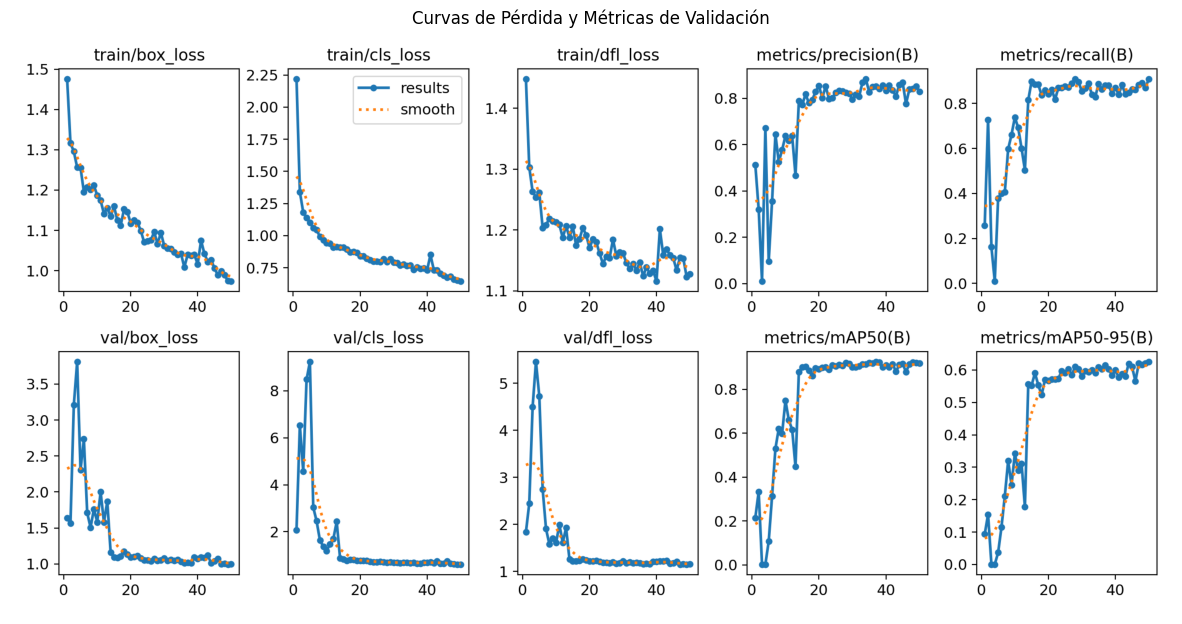

In [ ]:
# Ultralytics guarda automáticamente un resumen del entrenamiento en el archivo 'results.png'
img_path = f'{save_dir}/results.png'

try:
    img = mpimg.imread(img_path)
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Curvas de Pérdida y Métricas de Validación")
    plt.show()
except FileNotFoundError:
    print("El archivo de resultados visuales aún no se ha generado o la ruta es incorrecta.")


### 7. Modelo con Fine-Tuning en Datos de Validación

In [ ]:
metrics = model_ft.val(data="bccd.yaml", imgsz=640, split="val")
print("mAP@0.5 luego de Fine Tuning:", metrics.box.map50)

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 957.7±218.3 MB/s, size: 20.2 KB)
val: Scanning /content/datasets/BCCD/labels/val.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 25.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.3it/s 3.8s
                   all         73        964      0.829      0.908      0.919      0.624
                   RBC         69        821      0.747      0.848      0.877      0.628
                   WBC         71         72      0.964          1      0.988      0.793
             Platelets         40         71      0.776      0.877      0.894      0.451
Speed: 11.8ms preprocess, 8.9ms inference, 0.0ms loss, 6.1ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5 luego d

### 8. Explicación de cambios al Fine Tuning

Para lograr superar las estrictas métricas de mAP50-95 de las Tablas I y II, debes considerar la naturaleza del problema y las diferencias entre los datos originales del modelo y tu conjunto de datos.

1. Cambiar FREEZE_LAYERS = 10 a FREEZE_LAYERS = 0 (o un número muy bajo como 2):
Ajuste: Elimina o reduce drásticamente el congelamiento de capas.
Justificación: El modelo YOLOv8 pre-entrenado adquirió sus conocimientos iniciales del dataset COCO, el cual contiene 80 clases de objetos cotidianos (personas, autos, perros)
. Sin embargo, el dataset BCCD contiene imágenes microscópicas de células sanguíneas, las cuales tienen características visuales completamente distintas y que no existen en COCO
. Al congelar 10 capas (freeze=10)
, estás bloqueando gran parte de la red neuronal, impidiendo que aprenda estas nuevas formas y texturas. Permitir que todas (o casi todas) las capas actualicen sus pesos facilitará que el modelo se adapte profundamente a la morfología de las células y logre bounding boxes mucho más ajustados.

2. Aumentar EARLY_STOPPING_PATIENCE = 10 a 15 o 20:
Ajuste: Incrementa la tolerancia de épocas sin mejora.
Justificación: El parámetro patience detiene el entrenamiento tempranamente si las métricas no mejoran para evitar el sobreajuste
. Sin embargo, la métrica mAP50-95 es muy exigente porque evalúa la calidad de la detección en niveles altos de Intersection-over-Union (hasta 0.95), lo que requiere que los bordes de la caja delimitadora sean casi perfectos
. Este ajuste fino espacial a menudo toma tiempo y progresa lentamente. Si cortas el entrenamiento a las 10 épocas sin mejora, no le das la oportunidad a la red de hacer estos microajustes necesarios para elevar el mAP50-95.


3. Cambio de OPTIMIZE_TYPE:
Para poder superar las métricas mAP50-95 de las Tablas I y II, se modificó el optimizador por defecto a "AdamW", el cual ha demostrado ser más eficiente para convergencia rápida en conjuntos de datos pequeños (como el BCCD, que posee pocos ejemplos en comparación con COCO)